<a href="https://colab.research.google.com/github/Twolvero/Skin-Lesion-Triage/blob/feature-extraction/feature-extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


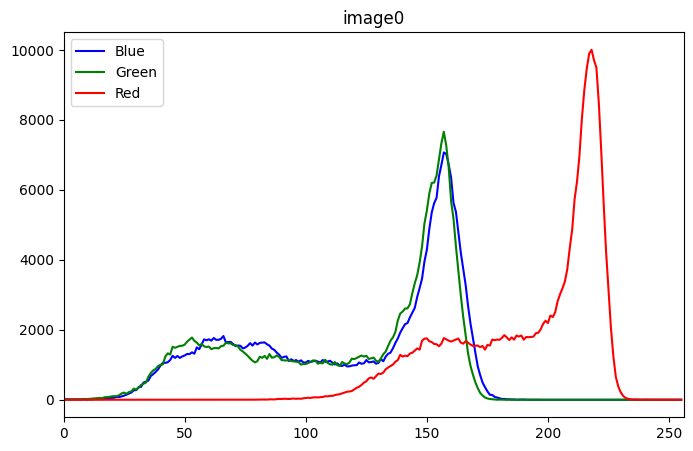

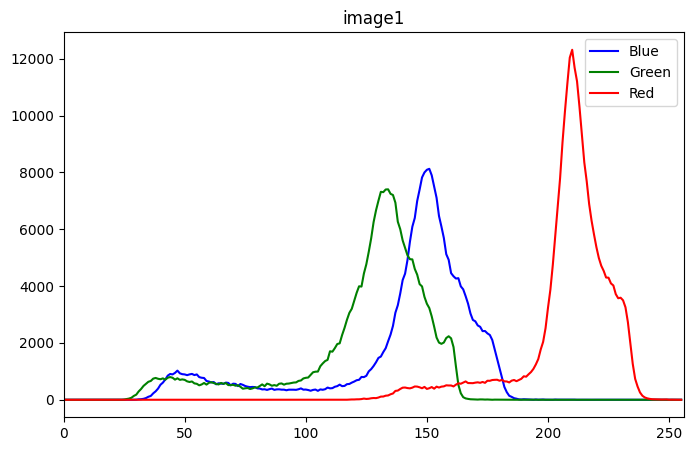

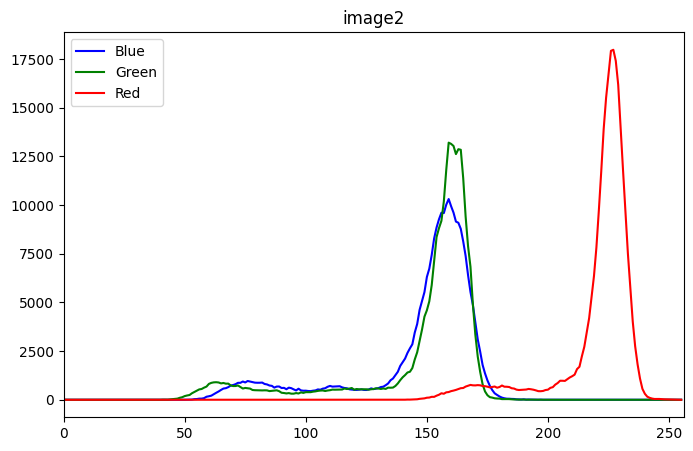

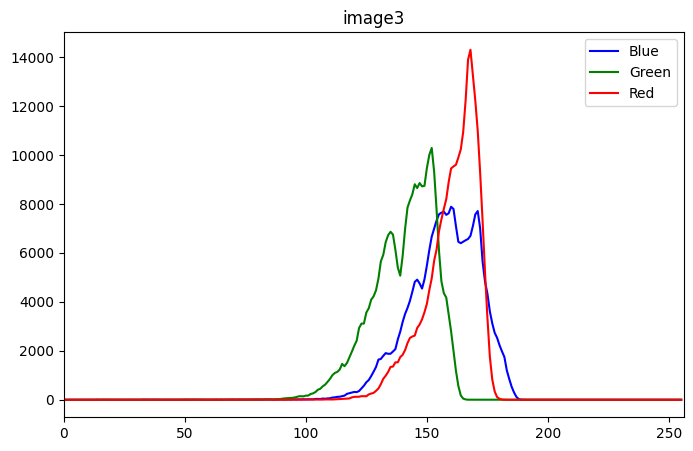

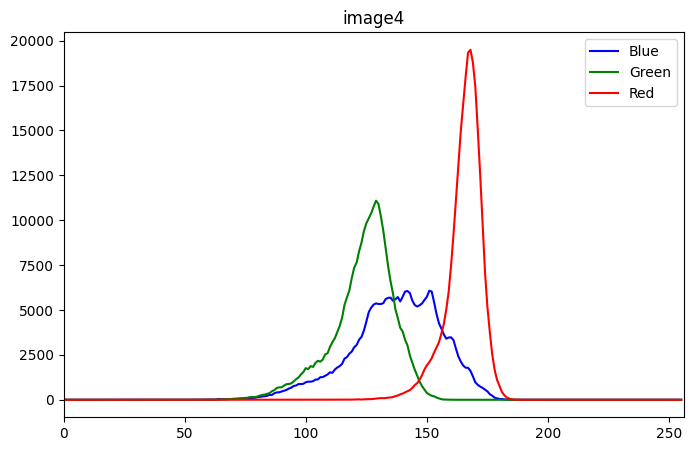

In [18]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

def load_images(num: int) -> tuple[list[np.ndarray], tuple[int, int, int]]:
    """
    load a specified number of images and return the images and their shape
    """
    path = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/'
    files = os.listdir(path)

    images = []

    for i in range(num):
        img = cv2.imread(path + files[i], cv2.IMREAD_COLOR)

        if img is None:
            print(f"Could not load image: {files[i]}")
            continue

        images.append(img)

    return images, img.shape

def create_hist(img: np.ndarray):
  """
  create a histogram (BGR) by taking an image
  """
  blue = cv2.calcHist([img], [0], None, [256], [0,256])
  green = cv2.calcHist([img], [1], None, [256], [0,256])
  red = cv2.calcHist([img], [2], None, [256], [0,256])
  return blue, green, red

def create_plots(imgs: list[np.ndarray]):
  for i, img in enumerate(imgs):
    blue, green, red = create_hist(img)
    plt.figure(figsize=(8,5))
    plt.plot(blue, color='b', label='Blue')
    plt.plot(green, color='g', label='Green')
    plt.plot(red, color='r', label='Red')
    plt.xlim([0,256])
    plt.title(f'image{i}')
    plt.legend()
    plt.show()

imgs, shape = load_images(5)
# print(imgs)
# print(shape)

create_plots(imgs)


#todo
- [ ] edge extraction
- [ ] needed values for the gaussian mixture model?